<a href="https://colab.research.google.com/github/ashutosh-kedar/pytorch_cv_food_101_tiny_vgg/blob/main/07_PyTorch_Custom_Dataset_Food_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
torch.__version__

'2.10.0+cpu'

In [ ]:
from pathlib import Path
import requests
import zipfile
def get_file_from_git(url,file_name,unzip_destination=None):
  file_to_download = Path(file_name)
  if file_to_download.is_file():
    print(f'{file_name} already exists')
  else:
    print(f'Downloading {file_name} from {url}')
    request = requests.get(url)
    with open(file_name,'wb') as file:
      file.write(request.content)

    if file_name.endswith('.zip'):
      with zipfile.ZipFile(file_name,'r') as zip_ref:
        print('Unzipping the zip file...')
        zip_ref.extractall(Path(unzip_destination))


In [ ]:
from pathlib import Path

get_file_from_git('https://raw.githubusercontent.com/ashutosh-kedar/pytorch_cv_food_101_tiny_vgg/main/structured_data.zip','structured_data.zip',unzip_destination='data/food_data')
data_path = Path('data/food_data')

# if data_path.is_dir():
#   print(f'{data_path} directory exists.')
# else:
#   print(f'Did not find {data_path} directory, creating one...')
#   request = requests.get('https://raw.githubusercontent.com/ashutosh-kedar/pytorch_cv_food_101_tiny_vgg/main/structured_data.zip')

#   with open('structured_data.zip','wb') as file:
#     file.write(request.content)

#   with zipfile.ZipFile('structured_data.zip','r') as zip_ref:
#     print('Unzipping the data...')
#     zip_ref.extractall(Path('data/food_data'))

Unzipping the zip file...


In [ ]:
import os

def walk_through_path(path:str):
  """ Prints the files and directory inside the path
  Args:
    path (str): The path to walk walk through

  Returns:
    None
  """
  for dirpath, dirnames, filenames in os.walk(path):
    print(f'There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}')

walk_through_path('data')

There are 1 directories and 0 images in data
There are 2 directories and 0 images in data/food_data
There are 3 directories and 0 images in data/food_data/train
There are 0 directories and 239 images in data/food_data/train/ice_cream
There are 0 directories and 231 images in data/food_data/train/pizza
There are 0 directories and 205 images in data/food_data/train/fried_rice
There are 3 directories and 0 images in data/food_data/test
There are 0 directories and 75 images in data/food_data/test/ice_cream
There are 0 directories and 76 images in data/food_data/test/pizza
There are 0 directories and 74 images in data/food_data/test/fried_rice


In [ ]:
train_dir = data_path / 'train'
test_dir = data_path / 'test'
train_dir,test_dir

(PosixPath('data/food_data/train'), PosixPath('data/food_data/test'))

Random Img Label: pizza


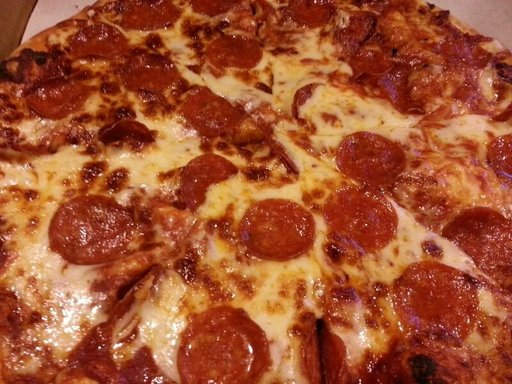

In [ ]:
import random
from PIL import Image

images_list = list(data_path.glob('*/*/*.jpg'))
random_img = random.choice(images_list)
random_img_label = random_img.parent.stem
random_img = Image.open(random_img)
print('Random Img Label:',random_img_label)
random_img

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

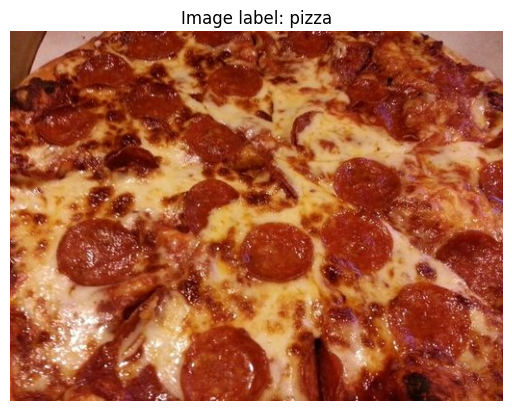

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

np_img_array = np.asarray(random_img)
np_img_array.shape

plt.imshow(np_img_array)
plt.title(f'Image label: {random_img_label}')
plt.axis(False)

###Image preprocessing pipeline practice

In [ ]:
from torchvision import transforms

random_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5)
])
random_transforms


Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    RandomHorizontalFlip(p=0.5)
)

<Figure size 1000x700 with 0 Axes>

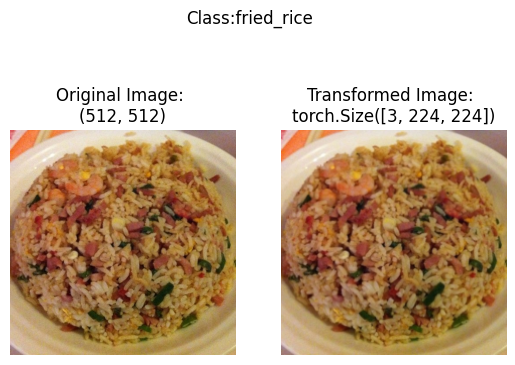

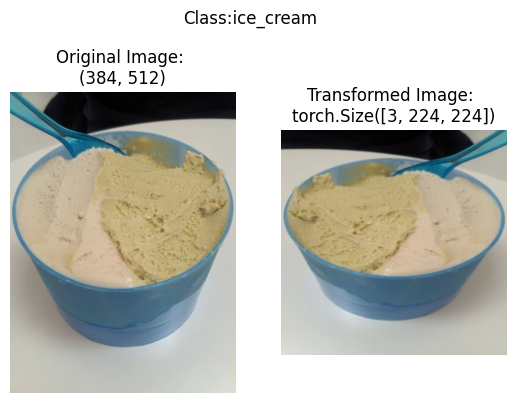

In [ ]:
import random
from PIL import Image
from matplotlib import pyplot as plt
number_of_samples = 2

plt.figure(figsize=(10,7))
for i in range(number_of_samples):
  random_img = random.choice(images_list)
  random_img_label = random_img.parent.stem
  with Image.open(random_img) as random_img:
    transformed_random_img = random_transforms(random_img)
    fig,ax = plt.subplots(1,2)
    ax[0].imshow(random_img)
    ax[0].axis(False)
    ax[0].set_title(f'Original Image: \n{random_img.size}')

    ax[1].imshow(transformed_random_img.permute(1,2,0))
    ax[1].axis(False)
    ax[1].set_title(f'Transformed Image: \n{transformed_random_img.shape}')

    fig.suptitle(f'Class:{random_img_label}')
    # fig.subplots_adjust(hspace=0.5,wspace=0.5)

In [ ]:
from torch.utils.data import Dataset
import os
from pathlib import Path
from PIL import Image


class CustomImageDataset(Dataset):

  def __init__(self,image_paths=str,transform=None):
    self.transform = transform
    self.image_paths = image_paths
    self.images = list(Path(image_paths).glob('*/*.jpg'))
    self.labels = [directory.name for directory in os.scandir(image_paths) if directory.is_dir()]
    self.class_to_idx = {idx: class_label for class_label,idx in enumerate(self.labels)}

  def __len__(self):
    return len(self.images)

  def __getitem__(self,idx):
    if idx >= len(self.images):
      raise IndexError(f'Index {idx} is out of range')
    image_path = self.images[idx]
    label = image_path.parent.stem
    with Image.open(image_path) as image:
      if self.transform:
        image = self.transform(image)
      return image,self.class_to_idx[label]


In [ ]:
custom_dataset = CustomImageDataset(image_paths=train_dir,transform=random_transforms)
print(custom_dataset.class_to_idx)
print(custom_dataset.labels)

{'ice_cream': 0, 'pizza': 1, 'fried_rice': 2}
['ice_cream', 'pizza', 'fried_rice']


In [ ]:
img,label = custom_dataset.__getitem__(0)
img

tensor([[[0.2196, 0.2353, 0.2471,  ..., 0.2706, 0.2353, 0.2235],
         [0.2039, 0.2275, 0.2353,  ..., 0.2627, 0.2275, 0.2157],
         [0.1882, 0.2078, 0.2157,  ..., 0.2588, 0.2275, 0.2118],
         ...,
         [0.1294, 0.1216, 0.1137,  ..., 0.0275, 0.0275, 0.0275],
         [0.1137, 0.0980, 0.0706,  ..., 0.0275, 0.0275, 0.0275],
         [0.1059, 0.0863, 0.0471,  ..., 0.0275, 0.0275, 0.0275]],

        [[0.0275, 0.0275, 0.0275,  ..., 0.0314, 0.0353, 0.0353],
         [0.0235, 0.0235, 0.0275,  ..., 0.0275, 0.0314, 0.0275],
         [0.0235, 0.0235, 0.0275,  ..., 0.0314, 0.0314, 0.0314],
         ...,
         [0.1098, 0.1098, 0.1098,  ..., 0.0275, 0.0275, 0.0275],
         [0.1098, 0.0941, 0.0784,  ..., 0.0275, 0.0275, 0.0275],
         [0.0980, 0.0824, 0.0627,  ..., 0.0275, 0.0275, 0.0275]],

        [[0.0275, 0.0275, 0.0235,  ..., 0.0275, 0.0235, 0.0235],
         [0.0235, 0.0275, 0.0275,  ..., 0.0275, 0.0196, 0.0196],
         [0.0275, 0.0314, 0.0275,  ..., 0.0314, 0.0275, 0.

In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5)
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_transforms,test_transforms

(Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     RandomHorizontalFlip(p=0.5)
 ),
 Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
 ))

In [ ]:
from torch.utils.data import DataLoader

train_dataset = CustomImageDataset(image_paths=train_dir,transform=train_transforms)
test_dataset = CustomImageDataset(image_paths=test_dir,transform=test_transforms)

train_data_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_data_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

train_data_loader,test_data_loader

(<torch.utils.data.dataloader.DataLoader at 0x794f24b3c890>,
 <torch.utils.data.dataloader.DataLoader at 0x794f24f48fe0>)

In [ ]:
from torch import nn


class TinyVgg(nn.Module):
  def __init__(self,input_size,hidden_size,output_size):
    super().__init__()
    self.conv1 = nn.Sequential(
      nn.Conv2d(in_channels=input_size,out_channels=hidden_size,kernel_size=3,stride=1,padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.conv2 = nn.Sequential(
      nn.Conv2d(in_channels=hidden_size,out_channels=hidden_size,kernel_size=3,stride=1,padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=hidden_size*56*56,out_features=output_size)
  )

  def forward(self,x):
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.classifier(x)
    return x



In [ ]:
tiny_vgg_model = TinyVgg(input_size=3,hidden_size=10,output_size=len(train_dataset.labels))
tiny_vgg_model

TinyVgg(
  (conv1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=31360, out_features=3, bias=True)
  )
)

In [ ]:
len(train_dataset.labels)

3

In [ ]:
try:
  import torchinfo
except:
  print('Installing torchinfo...')
  !pip install torchinfo


Installing torchinfo...


In [ ]:
from torchinfo import summary
summary(model=tiny_vgg_model,input_size=(32,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVgg                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 112, 112]        --
│    └─Conv2d: 2-1                       [32, 10, 224, 224]        280
│    └─ReLU: 2-2                         [32, 10, 224, 224]        --
│    └─MaxPool2d: 2-3                    [32, 10, 112, 112]        --
├─Sequential: 1-2                        [32, 10, 56, 56]          --
│    └─Conv2d: 2-4                       [32, 10, 112, 112]        910
│    └─ReLU: 2-5                         [32, 10, 112, 112]        --
│    └─MaxPool2d: 2-6                    [32, 10, 56, 56]          --
├─Sequential: 1-3                        [32, 3]                   --
│    └─Flatten: 2-7                      [32, 31360]               --
│    └─Linear: 2-8                       [32, 3]                   94,083
Total params: 95,273
Trainable params: 95,273
Non-trainable params: 0
Total mul

In [ ]:
def accuracy(pred,actual):
  true_predicted = torch.eq(pred,actual).count_nonzero().item()
  return true_predicted/len(actual)

In [ ]:
def train_step(model:nn.Module,dataloader:DataLoader,loss_fn,optimizer,device):
  total_loss = 0
  total_accuracy = 0
  model.train()
  model.to(device)

  for batch,data in enumerate(dataloader):
    img,label = data
    img,label = img.to(device),label.to(device)
    pred_logits = model(img.to(device))
    pred_values = torch.argmax(torch.softmax(pred_logits,dim=1),dim=1)

    loss = loss_fn(pred_logits,label)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    total_loss += loss.item()
    total_accuracy += accuracy(pred_values,label)

  total_loss = total_loss/len(dataloader)

  return total_loss,total_accuracy

In [ ]:
def test_step(model:nn.Module,dataloader:DataLoader,loss_fn,device):
  model.eval()
  model.to(device)
  total_loss = 0
  total_accuracy = 0
  with torch.inference_mode():
    for data in dataloader:
      img,label = data
      img,label = img.to(device),label.to(device)
      pred_logits = model(img.to(device))
      pred_values = torch.argmax(torch.softmax(pred_logits,dim=1),dim=1)
      loss = loss_fn(pred_logits,label)

      total_accuracy += accuracy(pred_values,label)
      total_loss += loss.item()

  total_loss = total_loss / len(dataloader)
  total_accuracy = total_accuracy / len(dataloader)
  return total_loss,total_accuracy



In [ ]:
from tqdm.auto import tqdm

def train_model(model:nn.Module,train_dataloader,test_dataloader,optimizer,loss_fn,epochs,device):
  model.to(device)
  results = {'train_loss':[],'train_accuracy':[],'test_loss':[],'test_accuracy':[]}
  for epoch in tqdm(range(epochs)):
    train_loss,train_accuracy = train_step(model=model,dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,device=device)
    test_loss,test_accuracy = test_step(model=model,dataloader=test_dataloader,loss_fn=loss_fn,device=device)
    print(f'Epoch: {epoch} | Train Loss: {train_loss} | Train Accuracy: {train_accuracy} | Test Loss: {test_loss} | Test Accuracy: {test_accuracy}')
    results.get('train_loss').append(train_loss)
    results.get('train_accuracy').append(train_accuracy)
    results.get('test_loss').append(test_loss)
    results.get('test_accuracy').append(test_accuracy)
  return results


In [ ]:
EPOCHS = 5
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = TinyVgg(input_size=3,hidden_size=10,output_size=len(train_dataset.labels))
# print(next(model.parameters()).device)
model.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),lr=0.001)
results = train_model(model=model,train_dataloader=train_data_loader,test_dataloader=train_data_loader,optimizer=optimizer,loss_fn=loss_fn,epochs=EPOCHS,device=device)
print(results)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.3110818158496509 | Train Accuracy: 8.510416666666666 | Test Loss: 1.0804091746156865 | Test Accuracy: 0.3821022727272727
Epoch: 1 | Train Loss: 1.0677898092703386 | Train Accuracy: 9.114583333333334 | Test Loss: 1.0338733169165524 | Test Accuracy: 0.4384469696969697
Epoch: 2 | Train Loss: 1.0291641300374812 | Train Accuracy: 10.34375 | Test Loss: 1.0016232485120946 | Test Accuracy: 0.5506628787878788
Epoch: 3 | Train Loss: 1.0065321597186 | Train Accuracy: 12.083333333333334 | Test Loss: 0.9676519171758131 | Test Accuracy: 0.5984848484848485
Epoch: 4 | Train Loss: 0.9560085291212256 | Train Accuracy: 13.09375 | Test Loss: 0.8622330102053556 | Test Accuracy: 0.6278409090909091
{'train_loss': [1.3110818158496509, 1.0677898092703386, 1.0291641300374812, 1.0065321597186, 0.9560085291212256], 'train_accuracy': [8.510416666666666, 9.114583333333334, 10.34375, 12.083333333333334, 13.09375], 'test_loss': [1.0804091746156865, 1.0338733169165524, 1.0016232485120946, 0.96

In [ ]:

def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_accuracy']
    test_accuracy = results['test_accuracy']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

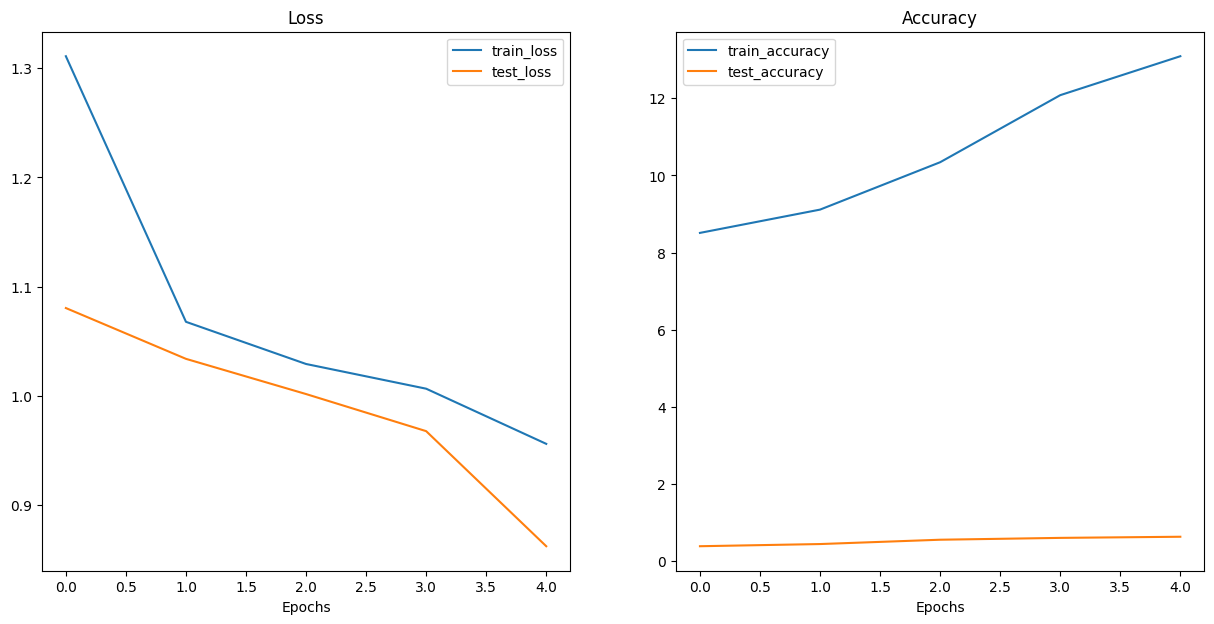

In [ ]:
plot_loss_curves(results)

In [ ]:
get_file_from_git('https://raw.githubusercontent.com/ashutosh-kedar/pytorch_cv_food_101_tiny_vgg/main/Ice_cream.jpg','Ice_cream.jpg')

In [ ]:
import numpy as np
def predict_image(model,image_path,class_names,transform,device):

  model.eval()
  model.to(device)
  with Image.open(image_path) as image:
    numpy_array = np.array(image)
    numpy_array = numpy_array / 255
    image = transform(image)
    image = image.unsqueeze(0)
    image = image.to(device)
    with torch.inference_mode():
      pred_logits = model(image)
      pred_label = torch.argmax(torch.softmax(pred_logits,dim=1),dim=1)

    plt.imshow(numpy_array)
    plt.title(f'Prediction: {class_names[pred_label]}')
    plt.axis(False)

    return class_names[pred_label],pred_logits


In [ ]:
train_dataset.labels
train_dataset.class_to_idx

{'ice_cream': 0, 'pizza': 1, 'fried_rice': 2}

('ice_cream', tensor([[ 0.5061, -0.4521, -0.6874]]))

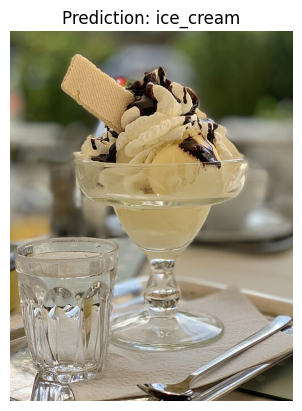

In [ ]:
custom_img_result = predict_image(model,'Ice_cream.jpg',train_dataset.labels,test_transforms,device)
custom_img_result

In [ ]:
from pathlib import Path
models_path = Path('models')

if not models_path.is_dir():
  models_path.mkdir(parents=True,exist_ok=True)

model_name = 'tiny_vgg_model.pth'

if not (models_path/model_name).is_file():
  print(f'Saving model in {model_name}')
  torch.save(obj=model.state_dict(),f=models_path/model_name)
else:
  print(f'{models_path/model_name} already exists')


Saving model
